# Week 02: Statistics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [4]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [5]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_34899/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_34899/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


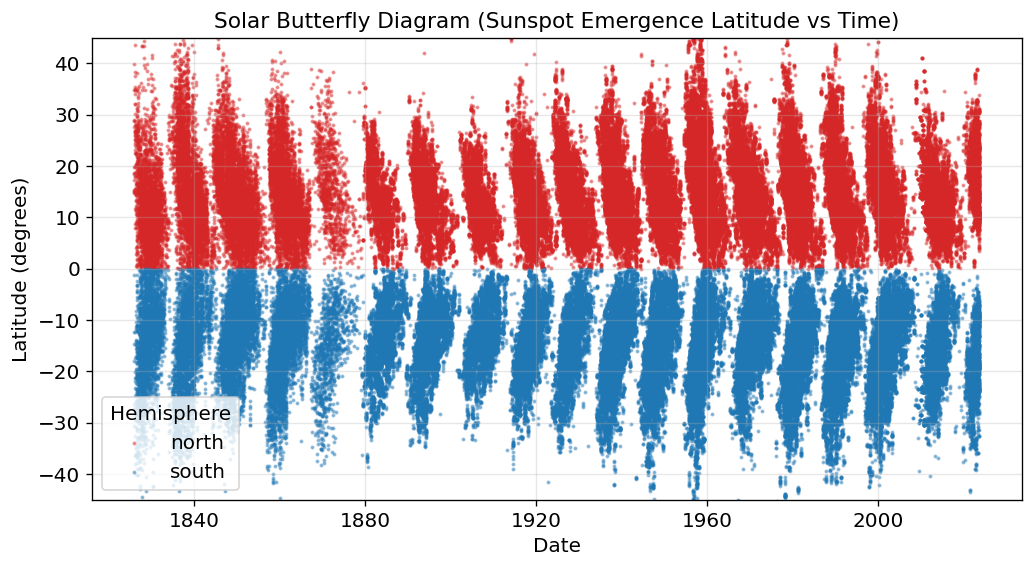

In [6]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


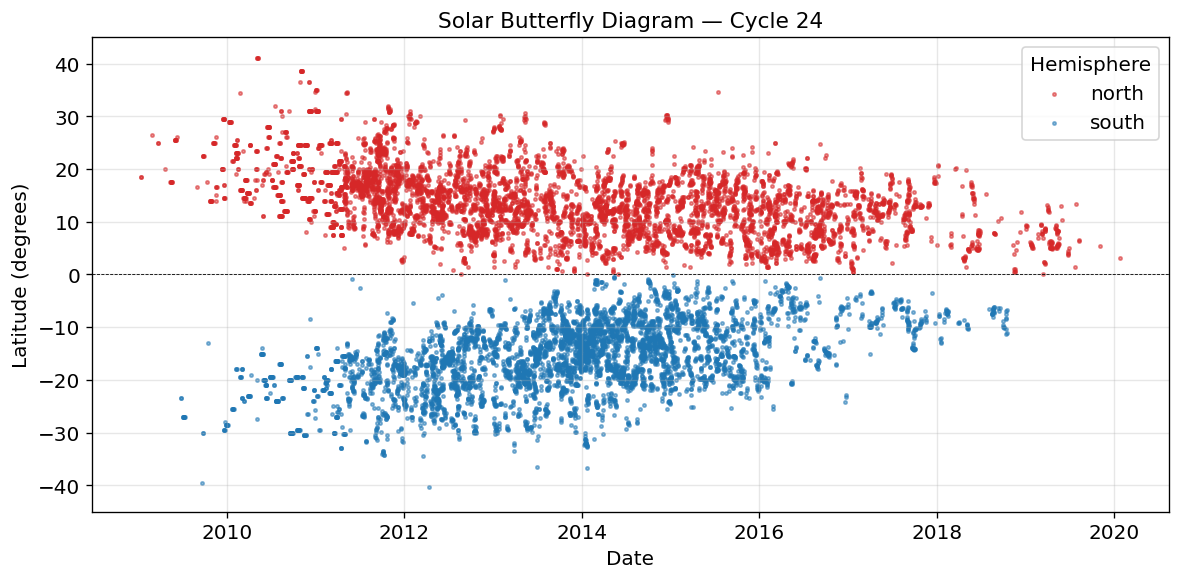

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [7]:
# Task 4: Visualize a single solar cycle
cycle_number = 24  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_34899/2015835256.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


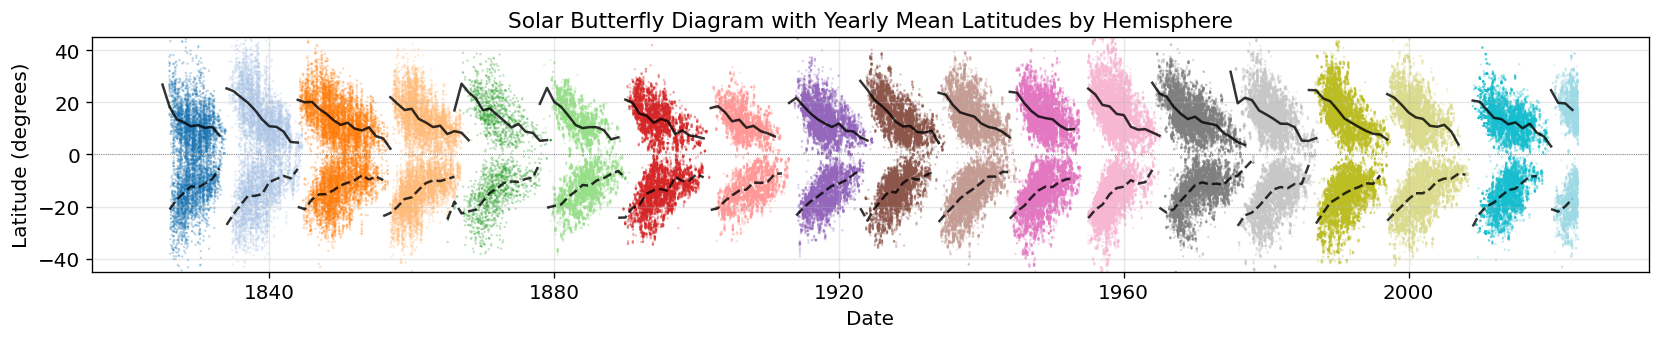

In [8]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2,
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}",
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]

    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black",
                linewidth=1.5, linestyle="-", alpha=0.8)

    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black",
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

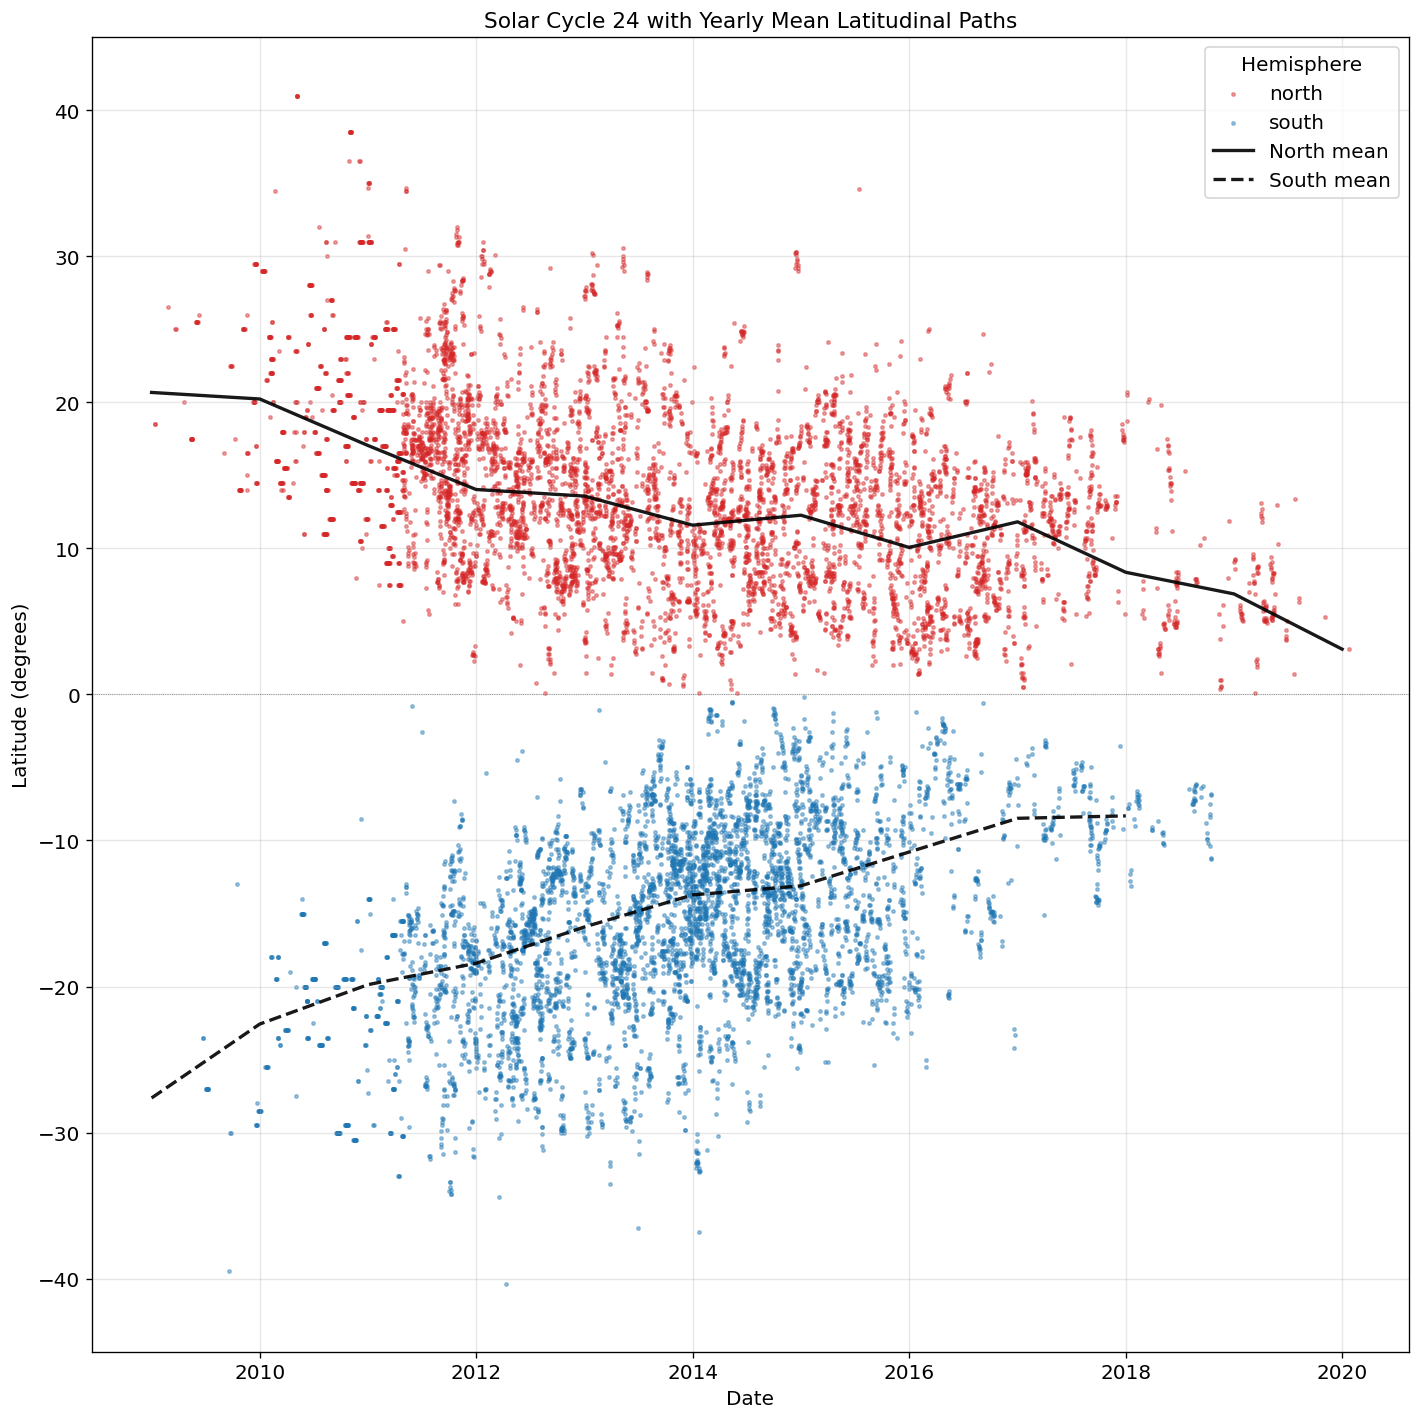

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [9]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:red"), ("south", "tab:blue")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black",
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black",
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


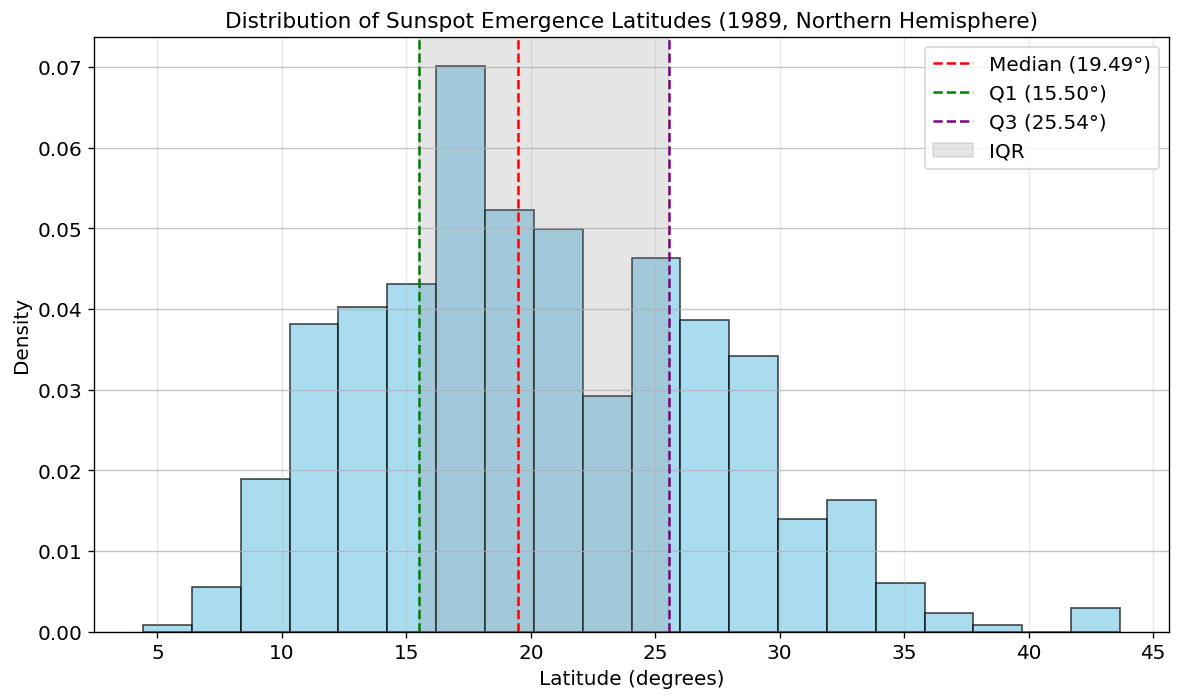

For 1989, Northern Hemisphere:
  Median Latitude: 19.49°
  Q1 (25th percentile): 15.50°
  Q3 (75th percentile): 25.54°
  IQR: 10.04°


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Define the year and hemisphere for analysis
selected_year = 1989
selected_hemisphere = "north" # Can be "north" or "south"

# Filter the data for the selected year and hemisphere
df_filtered = df[(df["date"].dt.year == selected_year) & (df["hemisphere"] == selected_hemisphere)].copy()

# Extract latitudes for the filtered data
latitudes = df_filtered["latitude"]

# Calculate median, Q1, and Q3
median_lat = np.median(latitudes)
q1_lat = np.percentile(latitudes, 25)
q3_lat = np.percentile(latitudes, 75)

# Plotting the histogram
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(latitudes, bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black')

# Add vertical lines for median, Q1, and Q3
ax.axvline(median_lat, color='red', linestyle='dashed', linewidth=1.5, label=f'Median ({median_lat:.2f}°)')
ax.axvline(q1_lat, color='green', linestyle='dashed', linewidth=1.5, label=f'Q1 ({q1_lat:.2f}°)')
ax.axvline(q3_lat, color='purple', linestyle='dashed', linewidth=1.5, label=f'Q3 ({q3_lat:.2f}°)')

# Shade the Interquartile Range (IQR)
ax.axvspan(q1_lat, q3_lat, color='gray', alpha=0.2, label='IQR')

ax.set_title(f'Distribution of Sunspot Emergence Latitudes ({selected_year}, {selected_hemisphere.capitalize()}ern Hemisphere)')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

print(f"For {selected_year}, {selected_hemisphere.capitalize()}ern Hemisphere:")
print(f"  Median Latitude: {median_lat:.2f}°")
print(f"  Q1 (25th percentile): {q1_lat:.2f}°")
print(f"  Q3 (75th percentile): {q3_lat:.2f}°")
print(f"  IQR: {q3_lat - q1_lat:.2f}°")


## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


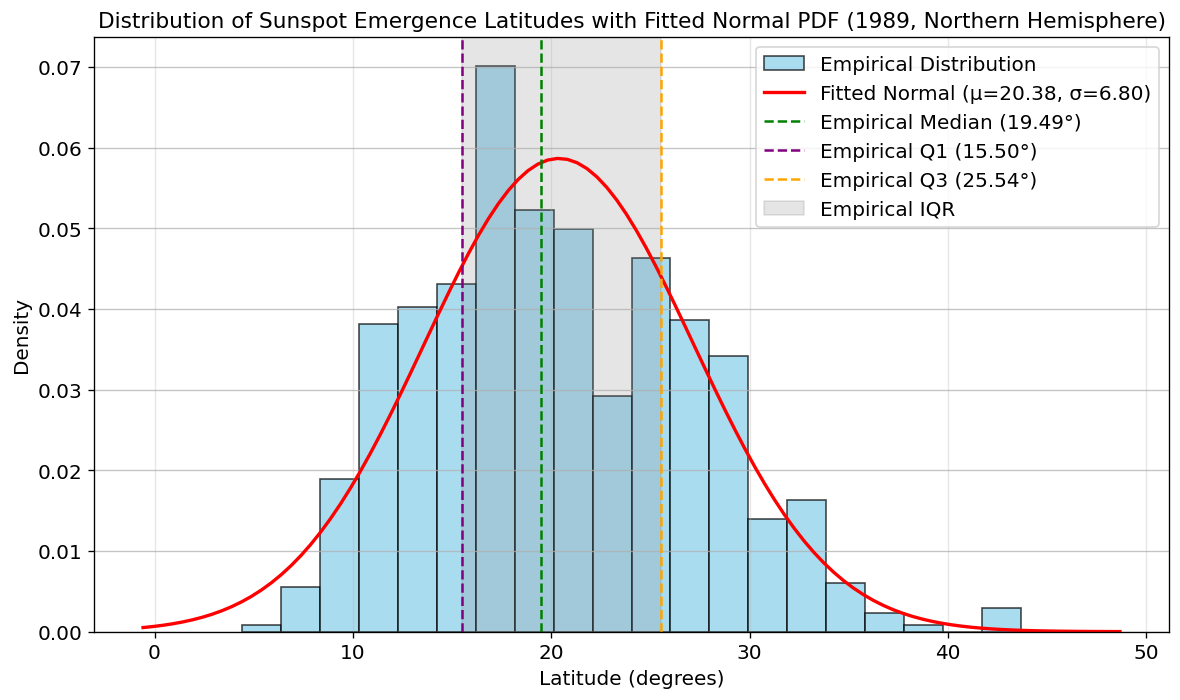

For 1989, Northern Hemisphere:
  Fitted Normal Distribution Parameters: Mean (μ) = 20.38°, Standard Deviation (σ) = 6.80°
  Empirical Mean Latitude: 20.38°
  Empirical Median Latitude: 19.49°
  Empirical Q1 (25th percentile): 15.50°
  Empirical Q3 (75th percentile): 25.54°
  Empirical IQR: 10.04°

  Empirical 16th Percentile: 13.13° (compare to μ - σ = 13.58°)
  Empirical 84th Percentile: 27.56° (compare to μ + σ = 27.18°)


In [28]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Using the same year and hemisphere as a previous plot for consistency
selected_year = 1989
selected_hemisphere = "north" # Can be "north" or "south"

df_filtered = df[(df["date"].dt.year == selected_year) & (df["hemisphere"] == selected_hemisphere)].copy()
latitudes = df_filtered["latitude"]

# Fit a Normal distribution to the data
mu, sigma = norm.fit(latitudes)

# Create a range of x values for the PDF
x = np.linspace(latitudes.min() - 5, latitudes.max() + 5, 100)
pdf_fit = norm.pdf(x, mu, sigma)

# Calculate empirical mean, median, Q1, and Q3
mean_lat = np.mean(latitudes)
median_lat = np.median(latitudes)
q1_lat = np.percentile(latitudes, 25)
q3_lat = np.percentile(latitudes, 75)

# Calculate empirical 16th and 84th percentiles for comparison with mu +/- sigma
p16_lat = np.percentile(latitudes, 16)
p84_lat = np.percentile(latitudes, 84)

# Plotting the histogram with the fitted PDF
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(latitudes, bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Empirical Distribution')
ax.plot(x, pdf_fit, color='red', linestyle='-', linewidth=2, label=f'Fitted Normal (μ={mu:.2f}, σ={sigma:.2f})')

# Add vertical lines for empirical median, Q1, and Q3
ax.axvline(median_lat, color='green', linestyle='dashed', linewidth=1.5, label=f'Empirical Median ({median_lat:.2f}°)')
ax.axvline(q1_lat, color='purple', linestyle='dashed', linewidth=1.5, label=f'Empirical Q1 ({q1_lat:.2f}°)')
ax.axvline(q3_lat, color='orange', linestyle='dashed', linewidth=1.5, label=f'Empirical Q3 ({q3_lat:.2f}°)')
ax.axvspan(q1_lat, q3_lat, color='gray', alpha=0.2, label='Empirical IQR')

ax.set_title(f'Distribution of Sunspot Emergence Latitudes with Fitted Normal PDF ({selected_year}, {selected_hemisphere.capitalize()}ern Hemisphere)')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

print(f"For {selected_year}, {selected_hemisphere.capitalize()}ern Hemisphere:")
print(f"  Fitted Normal Distribution Parameters: Mean (μ) = {mu:.2f}°, Standard Deviation (σ) = {sigma:.2f}°")
print(f"  Empirical Mean Latitude: {mean_lat:.2f}°")
print(f"  Empirical Median Latitude: {median_lat:.2f}°")
print(f"  Empirical Q1 (25th percentile): {q1_lat:.2f}°")
print(f"  Empirical Q3 (75th percentile): {q3_lat:.2f}°")
print(f"  Empirical IQR: {q3_lat - q1_lat:.2f}°")
print(f"\n  Empirical 16th Percentile: {p16_lat:.2f}° (compare to μ - σ = {mu - sigma:.2f}°)")
print(f"  Empirical 84th Percentile: {p84_lat:.2f}° (compare to μ + σ = {mu + sigma:.2f}°)")

Comparing empirical values against the analytical approximated values, we see that the empirical median (19.49°) is not to far of from the fitted mean (20.38°), and comparing the emprirical 16th/84th percentiles against the analytical standard deviations, we also see a close match (13.13° and 27.56° vs. 13.58° and 27.18°, respectively). Still, we can qualitatively determine from the plot that the Gaussian distribution is not able to capture the irregularities and seemingly stochastic noise of the actual data.

A Guassian curve is completely described by its mean value μ and standard deviation σ. In the context of sunspot emergence, μ is the mean latitude of all sunspot observed in the given year, while σ sets an upper and lower boundary such that we can expect ∼68% of all sunspots to be located inside the resulting band.

## 8) Distribution Evolution Through a Solar Cycle

A single year's distribution is a snapshot. Over the course of a solar cycle, the distribution **drifts toward the equator** as the cycle ages — this is **Spörer's Law**, one of the most important empirical regularities in solar physics.

**Task:**
- Pick a solar cycle (e.g. cycle 24) and a hemisphere, and filter the data to both.
- For each year in that cycle, compute a **KDE (kernel density estimate)** of emergence latitudes.
- Plot all the KDEs overlaid, colored by year so the time progression is clear.
- Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?

**Hint:** `scipy.stats.gaussian_kde` fits a smooth density to an array of values. The `bw_method` parameter controls smoothing — try values between 0.2 and 0.5.


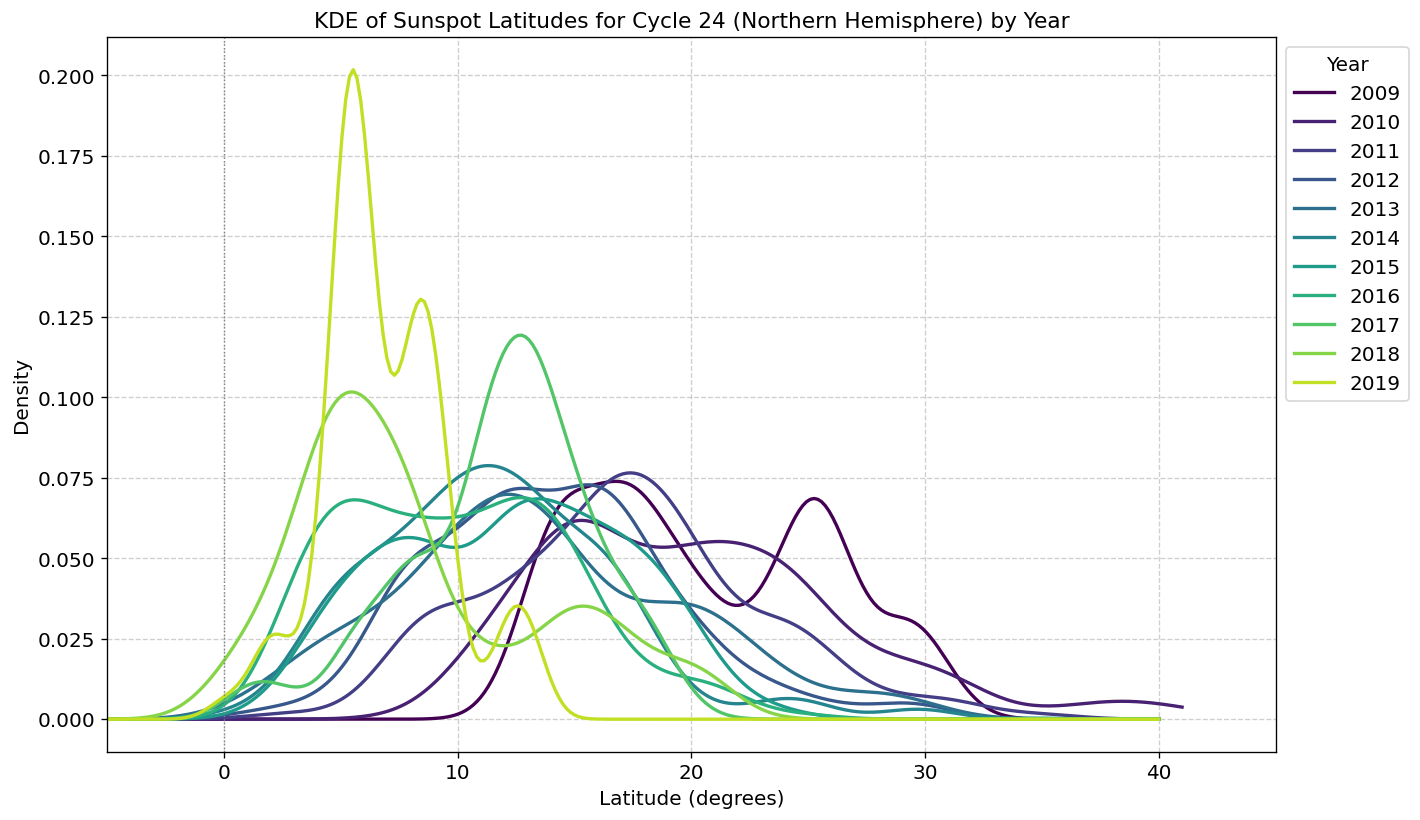

Solar Cycle 24, Northern Hemisphere:
  Years: 2009 - 2020
  Total N groups in cycle/hemisphere: 6,473


In [33]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Define the solar cycle and hemisphere for analysis
cycle_number = 24  # Change this to explore other cycles (e.g., 22, 23)
selected_hemisphere = "north" # Can be "north" or "south"

# Filter the data for the selected cycle and hemisphere
df_cycle_hemi = df[(df["CYCLE"] == cycle_number) & (df["hemisphere"] == selected_hemisphere)].copy()

# Ensure 'year' column is available
if 'year' not in df_cycle_hemi.columns:
    df_cycle_hemi["year"] = df_cycle_hemi["date"].dt.year

# Get unique years in the selected cycle and hemisphere
years_in_cycle = sorted(df_cycle_hemi["year"].unique())

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Define a colormap for years within the cycle
cmap = plt.get_cmap('viridis', len(years_in_cycle))

# Loop through each year, compute KDE, and plot
for i, year in enumerate(years_in_cycle):
    # Filter data for the current year
    latitudes_year = df_cycle_hemi[df_cycle_hemi["year"] == year]["latitude"].values

    # Only compute KDE if there's enough data (at least 2 points)
    if len(latitudes_year) > 1:
        # Compute Kernel Density Estimate
        kde = gaussian_kde(latitudes_year, bw_method=0.3) # Experiment with bw_method

        # Create a range of x values for plotting the KDE
        # Extend slightly beyond min/max latitudes for a smoother look
        x_vals = np.linspace(min(latitudes_year.min(), -40), max(latitudes_year.max(), 40), 500)

        # Evaluate the KDE on the x values
        pdf_vals = kde(x_vals)

        # Plot the KDE curve
        ax.plot(x_vals, pdf_vals, color=cmap(i), label=f'{year}', linewidth=2)

# Add plot details
ax.set_title(f'KDE of Sunspot Latitudes for Cycle {cycle_number} ({selected_hemisphere.capitalize()}ern Hemisphere) by Year')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend(title='Year', loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlim(-5, 45) # Ensure consistent latitude range
ax.axvline(0, color='grey', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

print(f"Solar Cycle {cycle_number}, {selected_hemisphere.capitalize()}ern Hemisphere:")
print(f"  Years: {min(years_in_cycle)} - {max(years_in_cycle)}")
print(f"  Total N groups in cycle/hemisphere: {len(df_cycle_hemi):,}")

From the plot we clearly see the distributions consolidating at the equator (0°) as the cycle progresses. We also see that sunspots are more spread out earlier in the cycle, with the variance appearing to decrease as the cycle approaches the equator.

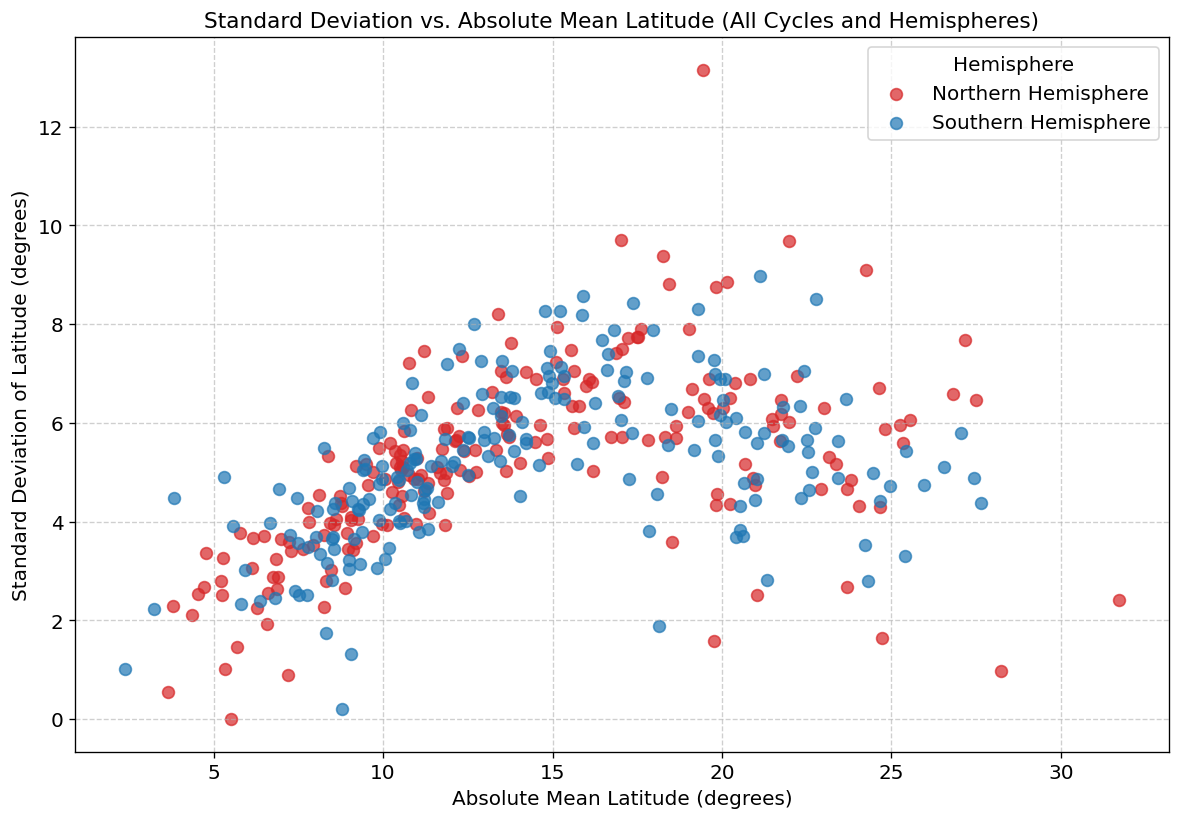

Pearson correlation between Absolute Mean Latitude and Standard Deviation (All Data): 0.44

Yearly Statistics (first 5 rows of aggregated mirrored data):
   CYCLE hemisphere  year  abs_mean_latitude  std_dev_latitude
0    7.0      north  1825          26.805714          6.579948
1    7.0      north  1826          18.248701          9.375948
2    7.0      north  1827          13.475319          7.050556
3    7.0      north  1828          12.342049          7.351530
4    7.0      north  1829          10.775706          7.215124


In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure 'year' and 'hemisphere' columns are available in df
if 'year' not in df.columns:
    df["year"] = df["date"].dt.year
if 'hemisphere' not in df.columns:
    df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")

# Create a new column with absolute latitude for mirroring effect
df['abs_latitude'] = df['latitude'].abs()

# Group by CYCLE, hemisphere, and year to get statistics for all data
# Now calculating mean and std dev on the absolute latitude
yearly_stats_all_mirrored = df.groupby(['CYCLE', 'hemisphere', 'year'])['abs_latitude'].agg(['mean', 'std']).reset_index()
yearly_stats_all_mirrored.rename(columns={'mean': 'abs_mean_latitude', 'std': 'std_dev_latitude'}, inplace=True)

# Drop rows with NaN values in CYCLE or std_dev_latitude
yearly_stats_all_mirrored = yearly_stats_all_mirrored.dropna(subset=['CYCLE', 'std_dev_latitude'])

# Create a scatter plot distinguishing hemispheres
fig, ax = plt.subplots(figsize=(10, 7))

colors = {'north': 'tab:red', 'south': 'tab:blue'}
for hemi, group in yearly_stats_all_mirrored.groupby('hemisphere'):
    ax.scatter(group['abs_mean_latitude'], group['std_dev_latitude'],
               color=colors[hemi], s=50, alpha=0.7, label=hemi.capitalize() + 'ern Hemisphere')

ax.set_title('Standard Deviation vs. Absolute Mean Latitude (All Cycles and Hemispheres)')
ax.set_xlabel('Absolute Mean Latitude (degrees)')
ax.set_ylabel('Standard Deviation of Latitude (degrees)')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Hemisphere')
plt.tight_layout()
plt.show()

# Calculate the Pearson correlation coefficient for all data points on mirrored latitudes
correlation_mirrored = yearly_stats_all_mirrored['abs_mean_latitude'].corr(yearly_stats_all_mirrored['std_dev_latitude'])
print(f"Pearson correlation between Absolute Mean Latitude and Standard Deviation (All Data): {correlation_mirrored:.2f}")

print("\nYearly Statistics (first 5 rows of aggregated mirrored data):")
print(yearly_stats_all_mirrored.head())

Comparing the absolute mean latitude with the corresponding standard deviation, we see further confirmation that σ decreases as |μ|→ 0. A Pearson correlation coefficient of 0.44 also indicates that the relation between the two parameters is somewhat linear (a behaviour that we also see mirrored in the plot).